SUPPORT AND RESISTANCE (50 DAYS)

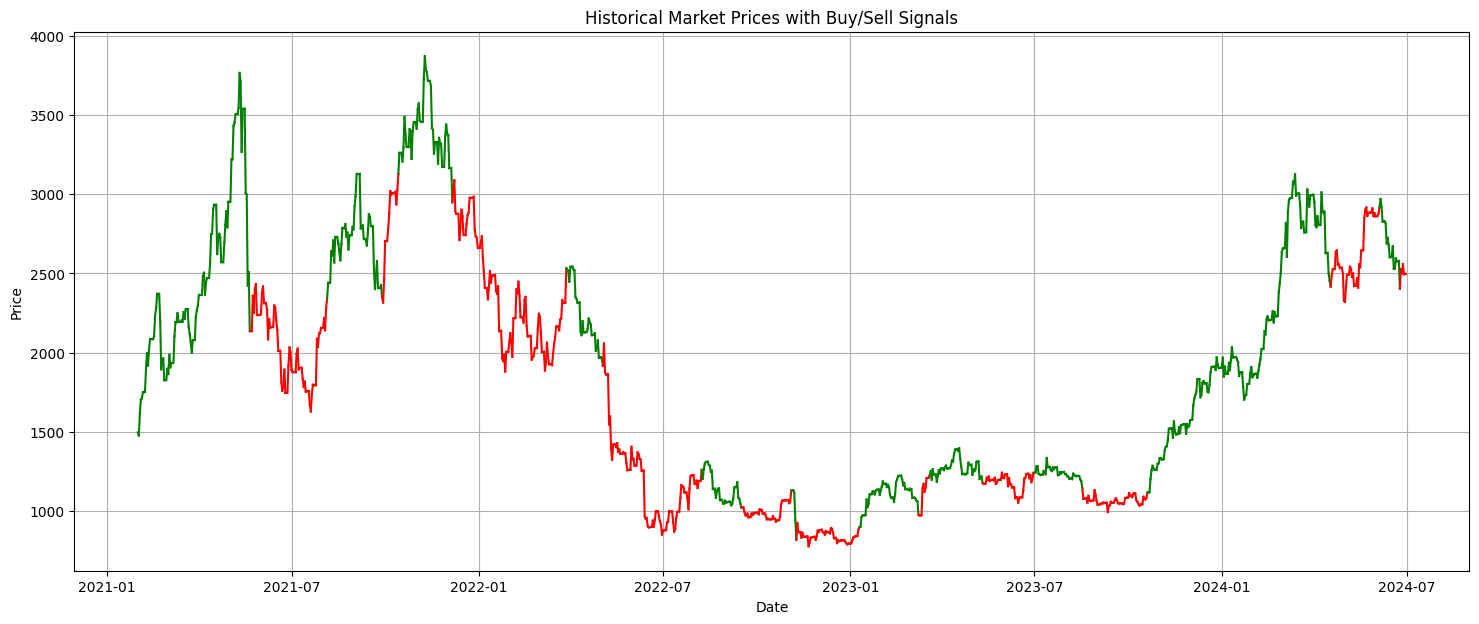

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/support_resist_50.csv') # Perform on CSV file

df = pd.DataFrame(data)

df['date'] = pd.to_datetime(df['date'])

dates = df['date']
prices = df['market']
signals = df['signs_with_no_0']


plt.figure(figsize=(18, 7))

for i in range(len(prices)-1):
    color = 'green' if signals[i] == 1 else 'red' if signals[i] == -1 else 'blue'
    plt.plot(dates[i:i+2], prices[i:i+2], color=color)

plt.title('Historical Market Prices with Buy/Sell Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

MACD

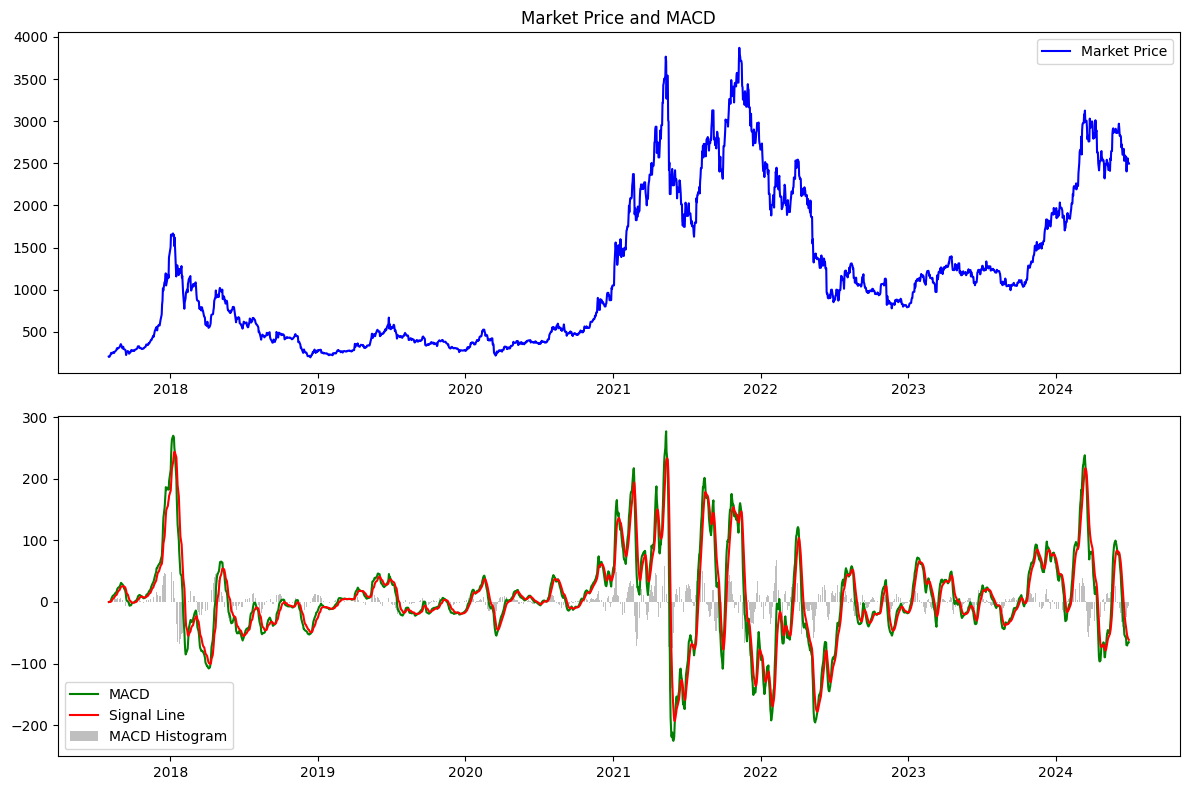

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/market_data.csv')

df = pd.DataFrame(data)

df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)

# Calculate the Short Term and Long Term EMA
short_ema = df['market'].ewm(span=12, adjust=False).mean()
long_ema = df['market'].ewm(span=26, adjust=False).mean()

# Calculate the MACD Line
df['MACD'] = short_ema - long_ema

# Calculate the Signal Line
df['Signal Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

# Calculate the MACD Histogram
df['MACD Histogram'] = df['MACD'] - df['Signal Line']

# Create a signals column
df['Signal'] = 0

# Generate buy and sell signals based on MACD value
df.loc[df['MACD'] >= 0, 'Signal'] = 1  # Buy signal
df.loc[df['MACD'] < 0, 'Signal'] = -1  # Sell signal

# Plotting
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(df.index, df['market'], label='Market Price', color='blue')
plt.title('Market Price and MACD')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(df.index, df['MACD'], label='MACD', color='green')
plt.plot(df.index, df['Signal Line'], label='Signal Line', color='red')
plt.bar(df.index, df['MACD Histogram'], label='MACD Histogram', color='gray', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(df['Signal'])

date
2017-08-02    0
2017-08-03    1
2017-08-04   -1
2017-08-07    1
2017-08-08    1
             ..
2024-06-26   -1
2024-06-27   -1
2024-06-28   -1
2024-06-29   -1
2024-06-30   -1
Name: Signal, Length: 2251, dtype: int64


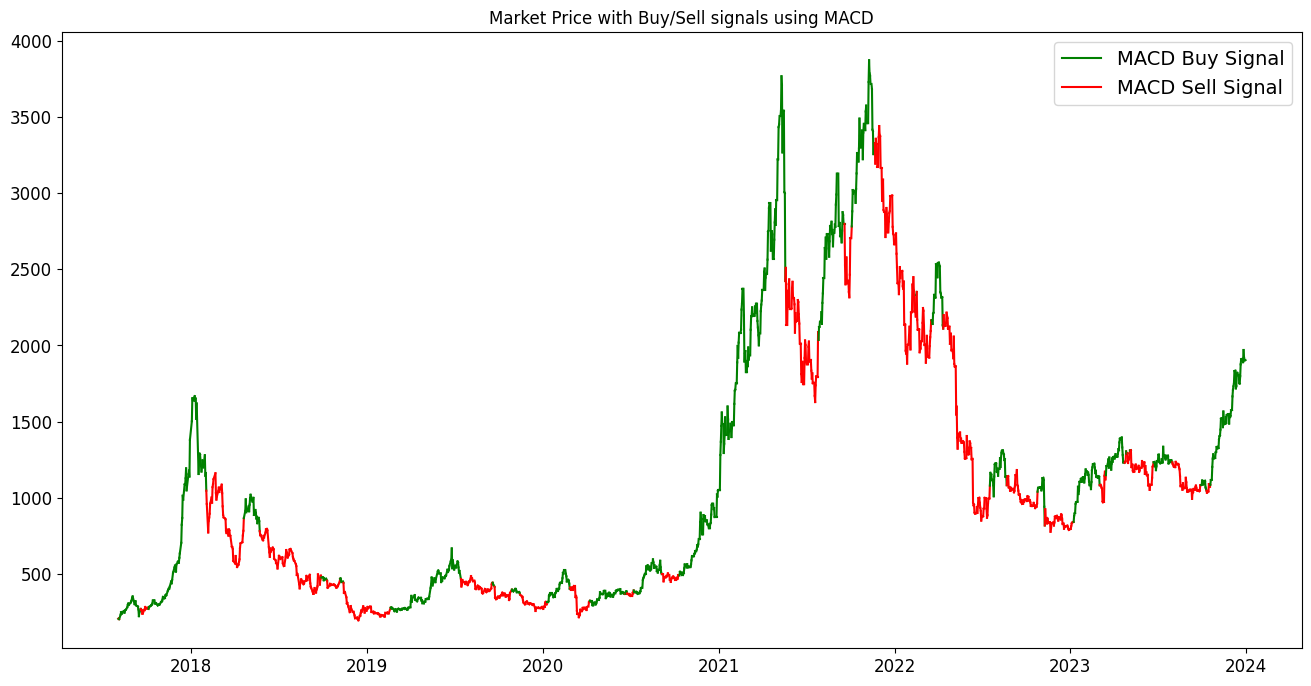

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/market_data.csv')

df = pd.DataFrame(data)

df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)

df = df[:'2023-12-31']

short_ema = df['market'].ewm(span=12, adjust=False).mean()
long_ema = df['market'].ewm(span=26, adjust=False).mean()

# Calculate the MACD Line
df['MACD'] = short_ema - long_ema

# Calculate the Signal Line
df['Signal Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

# Calculate the MACD Histogram
df['MACD Histogram'] = df['MACD'] - df['Signal Line']

# Initialize a signals column
df['Signal'] = 0

# Generate buy and sell signals based on MACD value
df.loc[df['MACD'] >= 0, 'Signal'] = 1  # Buy signal
df.loc[df['MACD'] < 0, 'Signal'] = -1  # Sell signal

# Plotting
plt.figure(figsize=(16, 8))

for i in range(1, len(df)):
    if df['Signal'].iloc[i] == 1:
        plt.plot(df.index[i-1:i+1], df['market'].iloc[i-1:i+1], color='green')
    elif df['Signal'].iloc[i] == -1:
        plt.plot(df.index[i-1:i+1], df['market'].iloc[i-1:i+1], color='red')
    else:
        plt.plot(df.index[i-1:i+1], df['market'].iloc[i-1:i+1], color='blue')

plt.plot([], [], color='green', label='MACD Buy Signal')
plt.plot([], [], color='red', label='MACD Sell Signal')

plt.title('Market Price with Buy/Sell signals using MACD')
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
df.to_csv('/content/MACD.csv')

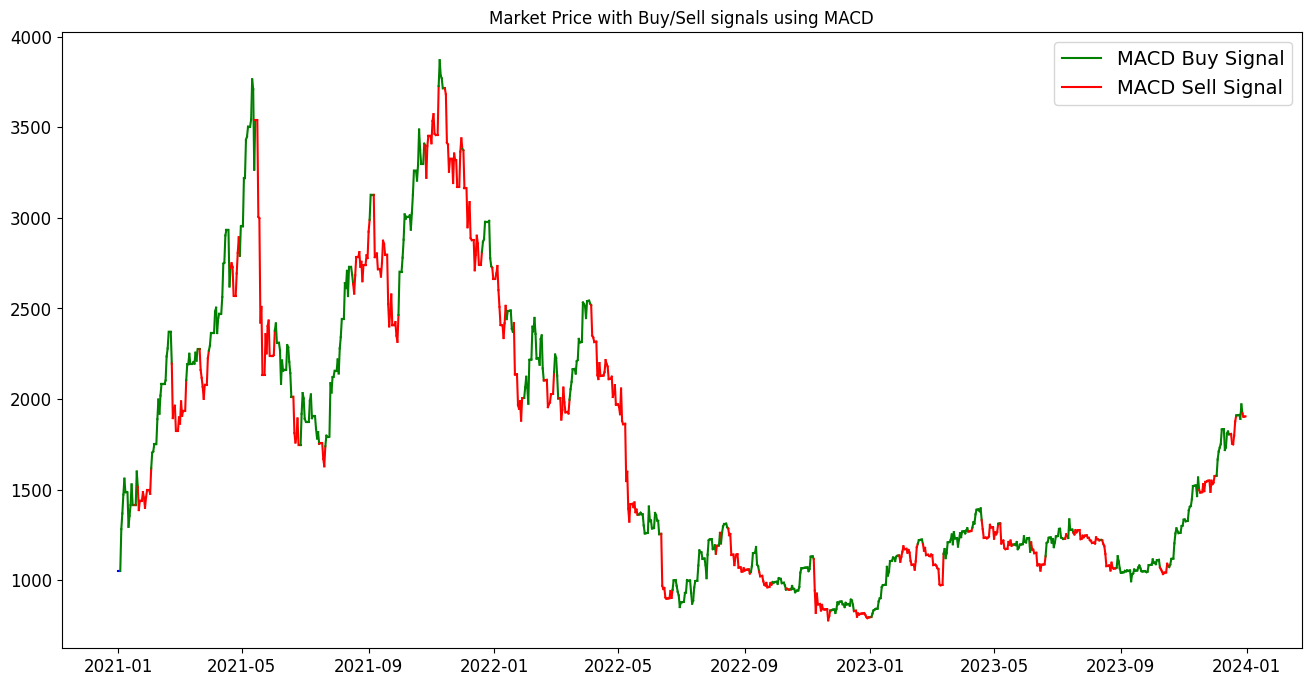

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/market_data.csv')

df = pd.DataFrame(data)

df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)

df = df['2021-01-01':'2023-12-31']

# Calculate the Short Term and Long Term EMA
short_ema = df['market'].ewm(span=12, adjust=False).mean()
long_ema = df['market'].ewm(span=26, adjust=False).mean()

# Calculate the MACD Line
df['MACD'] = short_ema - long_ema

# Calculate the Signal Line
df['Signal Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

# Calculate the MACD Histogram
df['MACD Histogram'] = df['MACD'] - df['Signal Line']

# Initialize a signals column
df['Signal'] = 0

# Generate buy and sell signals
df.loc[df['MACD'] > df['Signal Line'], 'Signal'] = 1  # Buy signal
df.loc[df['MACD'] < df['Signal Line'], 'Signal'] = -1  # Sell signal


# Plotting
plt.figure(figsize=(16, 8))

for i in range(1, len(df)):
    if df['Signal'].iloc[i] == 1:
        plt.plot(df.index[i-1:i+1], df['market'].iloc[i-1:i+1], color='green')
    elif df['Signal'].iloc[i] == -1:
        plt.plot(df.index[i-1:i+1], df['market'].iloc[i-1:i+1], color='red')
    else:
        plt.plot(df.index[i-1:i+1], df['market'].iloc[i-1:i+1], color='blue')

plt.plot([], [], color='green', label='MACD Buy Signal')
plt.plot([], [], color='red', label='MACD Sell Signal')

plt.title('Market Price with Buy/Sell signals using MACD')
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
df.to_csv('/content/MACD.csv')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/MACD.csv')

df = pd.DataFrame(data)

df['date'] = pd.to_datetime(df['date'])

dates = df['date']
prices = df['market']
signals = df['Signal']

plt.figure(figsize=(18, 7))

for i in range(len(prices)-1):
    color = 'green' if signals[i] == 1 else 'red' if signals[i] == -1 else 'blue'
    plt.plot(dates[i:i+2], prices[i:i+2], color=color)

plt.title('Historical Market Prices with Buy/Sell Signals using MACD')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

Market Index Cumulative Return

Average Daily Return: 0.12%
Average Daily Volatility: 3.68%
Annualized Return: 36.22%
Annualized Volatility: 58.40%
Annualized Sharpe Ratio: 0.6202
Cumulative Return: 81.17%
Max Drawdown: -79.89%


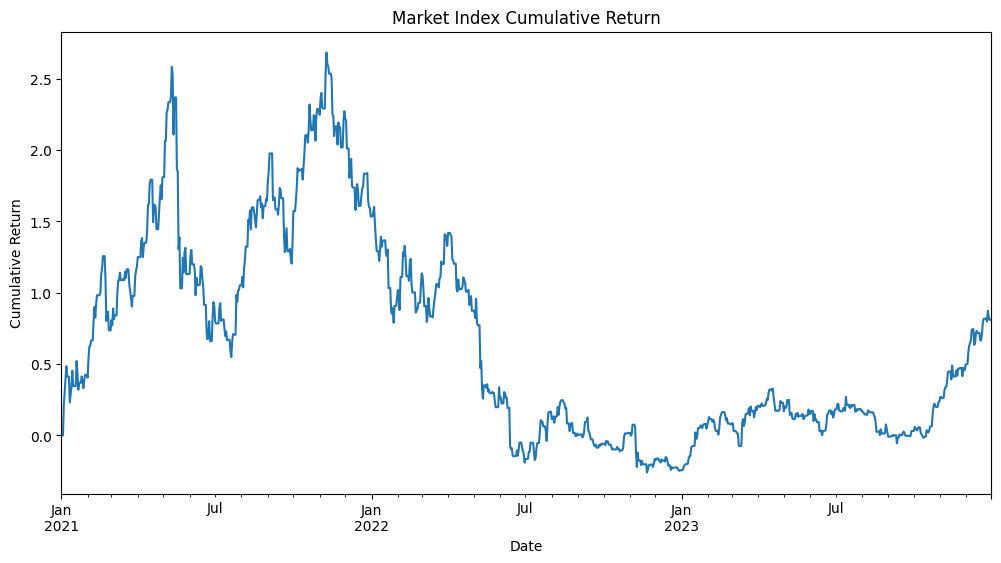

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('/content/market_data.csv')

market_data = pd.DataFrame(data)

market_data['date'] = pd.to_datetime(market_data['date'])

market_data.set_index('date', inplace=True)

market_data = market_data['2021-01-01':'2023-12-31'] # Limit the timeline

market_data['returns'] = market_data['market'].pct_change()

# Average Daily Return
average_daily_return = market_data['returns'].mean()

# Average Daily Volatility
average_daily_volatility = market_data['returns'].std()

# Annualized Return
trading_days_per_year = 252
annualized_return = (1 + average_daily_return) ** trading_days_per_year - 1

# Annualized Volatility
annualized_volatility = average_daily_volatility * np.sqrt(trading_days_per_year)

risk_free_rate = 0

# Annualized Sharpe Ratio
sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

# Cumulative Return
market_data['cumulative_return'] = (1 + market_data['returns']).cumprod() - 1

# Max Drawdown
cumulative = (1 + market_data['returns']).cumprod()
peak = cumulative.cummax()
drawdown = (cumulative - peak) / peak
max_drawdown = drawdown.min()

print(f"Average Daily Return: {average_daily_return * 100:.2f}%")
print(f"Average Daily Volatility: {average_daily_volatility * 100:.2f}%")
print(f"Annualized Return: {annualized_return * 100:.2f}%")
print(f"Annualized Volatility: {annualized_volatility * 100:.2f}%")
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.4f}")
print(f"Cumulative Return: {market_data['cumulative_return'].iloc[-1] * 100:.2f}%")
print(f"Max Drawdown: {max_drawdown * 100:.2f}%")

# Plot Cumulative Return
plt.figure(figsize=(12, 6))
market_data['cumulative_return'].plot(title='Market Index Cumulative Return')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

MA5 AND MA150 RULE

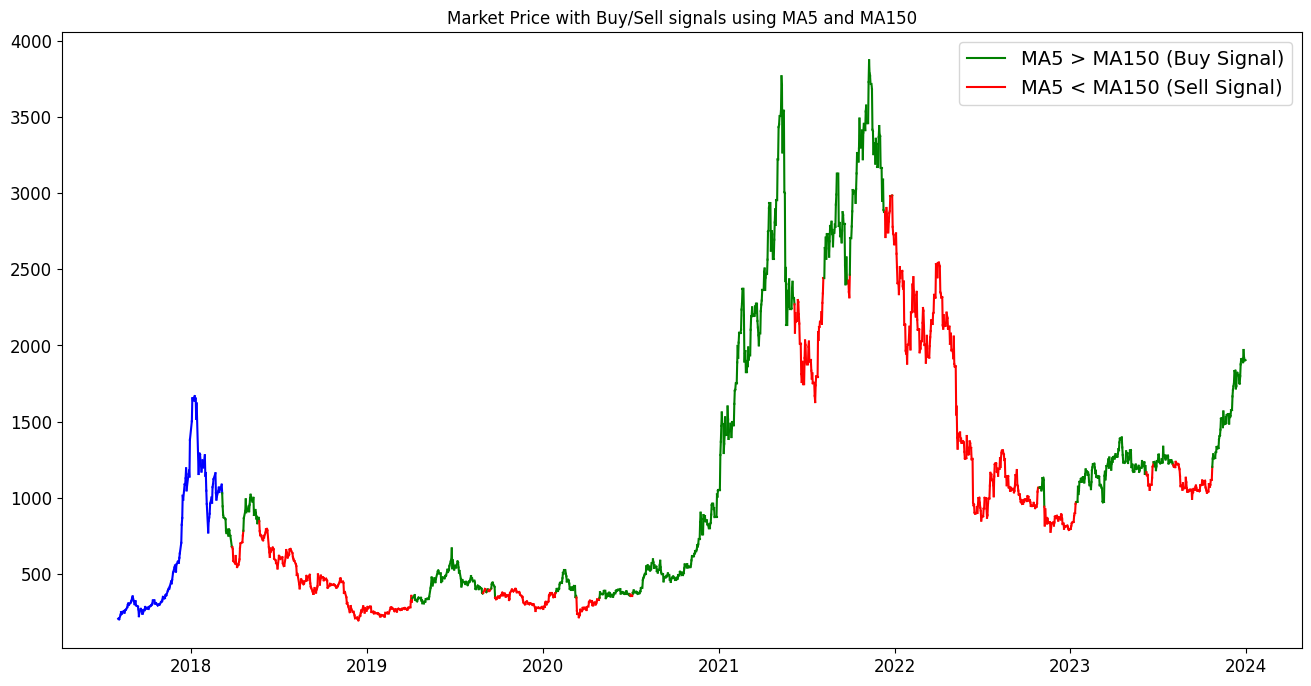

In [ ]:
'''MA5 AND MA150 RULE'''

import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/market_data.csv')

df = pd.DataFrame(data)

df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)

df = df[:'2023-12-31']

# Calculate the short-term (MA5) and long-term (MA150) moving averages
df['MA5'] = df['market'].rolling(window=5).mean()
df['MA150'] = df['market'].rolling(window=150).mean()

# Create a signals column
df['Signal'] = 0

# Generate buy signals when MA5 crosses above MA150
df.loc[df['MA5'] > df['MA150'], 'Signal'] = 1

# Generate sell signals when MA5 crosses below MA150
df.loc[df['MA5'] < df['MA150'], 'Signal'] = -1

plt.figure(figsize=(16, 8))

for i in range(1, len(df)):
    if df['Signal'].iloc[i] == 1:
        plt.plot(df.index[i-1:i+1], df['market'].iloc[i-1:i+1], color='green')
    elif df['Signal'].iloc[i] == -1:
        plt.plot(df.index[i-1:i+1], df['market'].iloc[i-1:i+1], color='red')
    else:
        plt.plot(df.index[i-1:i+1], df['market'].iloc[i-1:i+1], color='blue')

plt.plot([], [], color='green', label='MA5 > MA150 (Buy Signal)')
plt.plot([], [], color='red', label='MA5 < MA150 (Sell Signal)')

plt.title('Market Price with Buy/Sell signals using MA5 and MA150')
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
df.to_csv('/content/MA5&MA150.csv')

RELATUVE STRENGTH INDEX

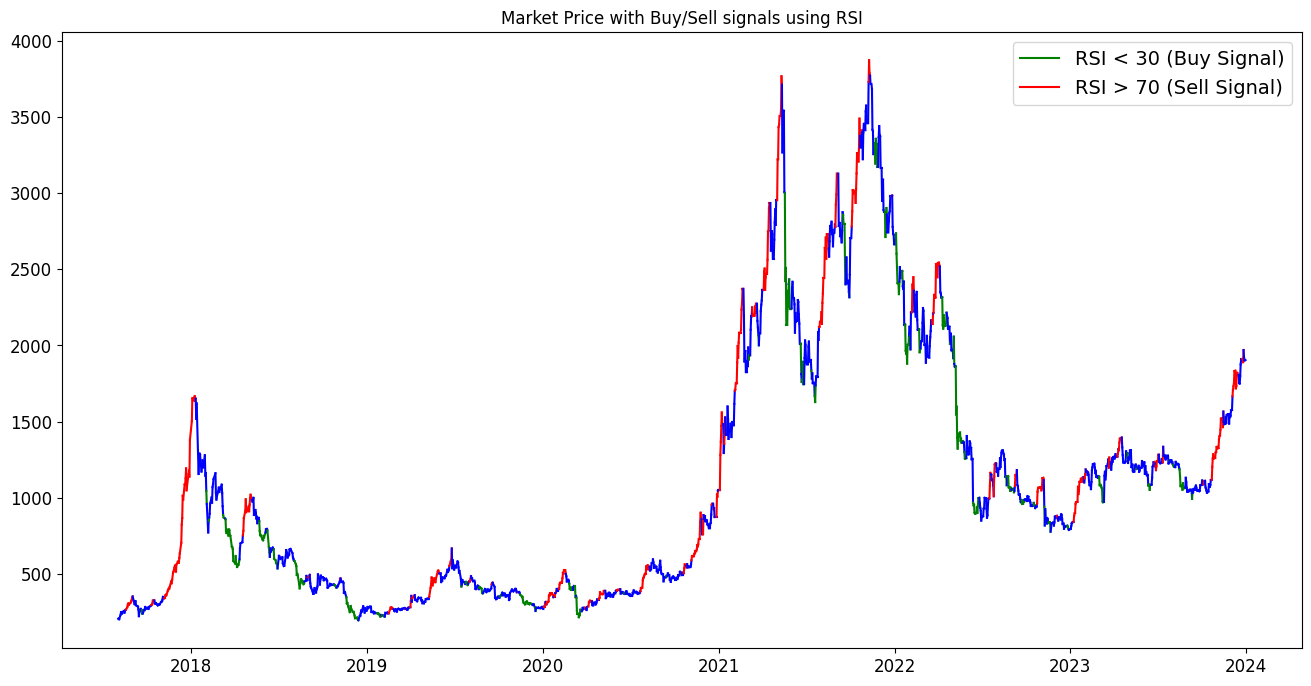

In [ ]:
'''RELATUVE STRENGTH INDEX'''

import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/market_data.csv')

df = pd.DataFrame(data)

df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)

df = df[:'2023-12-31']

# Calculate the RSI
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = calculate_rsi(df['market'])

# Create a signals column
df['Signal'] = 0

# Generate buy signals when RSI < 30
df.loc[df['RSI'] < 30, 'Signal'] = 1

# Generate sell signals when RSI > 70
df.loc[df['RSI'] > 70, 'Signal'] = -1

# Plotting
plt.figure(figsize=(16, 8))

for i in range(1, len(df)):
    if df['Signal'].iloc[i] == 1:
        plt.plot(df.index[i-1:i+1], df['market'].iloc[i-1:i+1], color='green')
    elif df['Signal'].iloc[i] == -1:
        plt.plot(df.index[i-1:i+1], df['market'].iloc[i-1:i+1], color='red')
    else:
        plt.plot(df.index[i-1:i+1], df['market'].iloc[i-1:i+1], color='blue')

plt.plot([], [], color='green', label='RSI < 30 (Buy Signal)')
plt.plot([], [], color='red', label='RSI > 70 (Sell Signal)')

plt.title('Market Price with Buy/Sell signals using RSI')
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
df.to_csv('/content/RSI.csv')

RATE OF CHANGE (ROC)

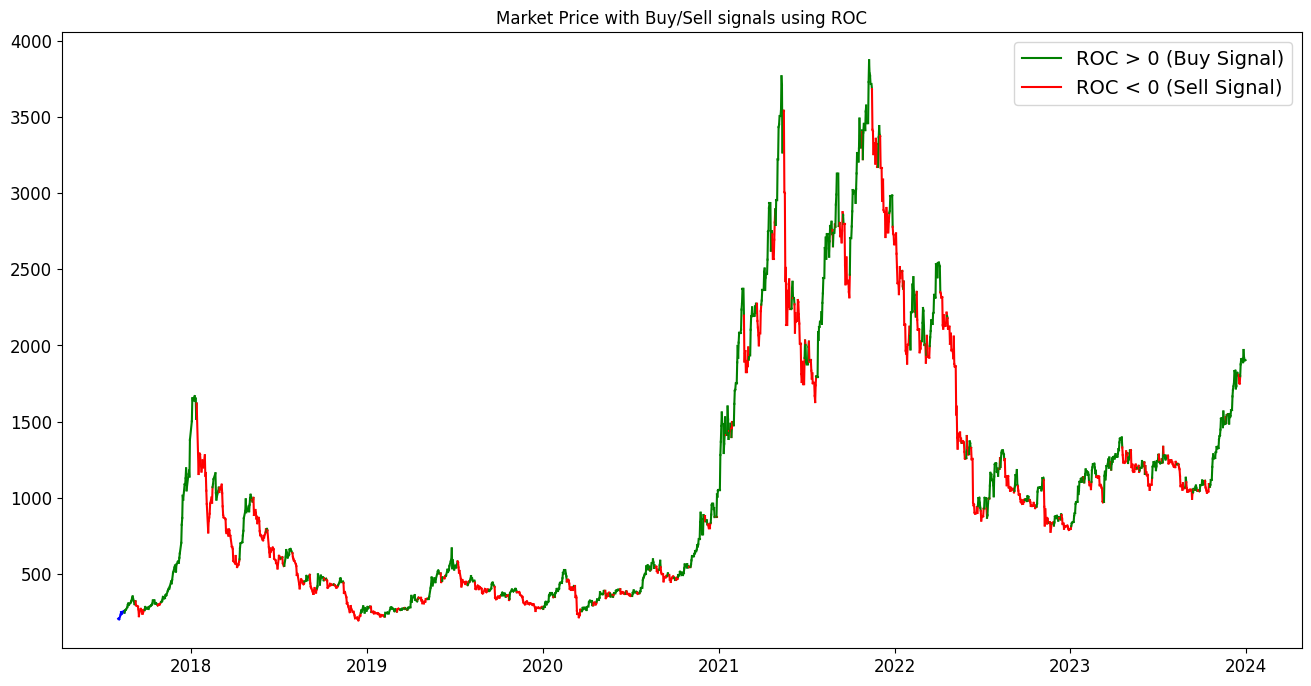

In [ ]:
'''RATE OF CHANGE (ROC)'''

import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/market_data.csv')

df = pd.DataFrame(data)

df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)

df = df[:'2023-12-31']

# Calculate the Rate of Change (ROC)
df['ROC'] = df['market'].pct_change(periods=10) * 100  # 10 days period

# Create a signals column
df['Signal'] = 0

# Generate buy signals when ROC > 0 (positive momentum)
df.loc[df['ROC'] > 0, 'Signal'] = 1

# Generate sell signals when ROC < 0 (negative momentum)
df.loc[df['ROC'] < 0, 'Signal'] = -1

# Plotting
plt.figure(figsize=(16, 8))

for i in range(1, len(df)):
    if df['Signal'].iloc[i] == 1:
        plt.plot(df.index[i-1:i+1], df['market'].iloc[i-1:i+1], color='green')
    elif df['Signal'].iloc[i] == -1:
        plt.plot(df.index[i-1:i+1], df['market'].iloc[i-1:i+1], color='red')
    else:
        plt.plot(df.index[i-1:i+1], df['market'].iloc[i-1:i+1], color='blue')

plt.plot([], [], color='green', label='ROC > 0 (Buy Signal)')
plt.plot([], [], color='red', label='ROC < 0 (Sell Signal)')

plt.title('Market Price with Buy/Sell signals using ROC')
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()